In [1]:
import os 
import pandas as pd
import glob

In [2]:
log_paths = glob.glob('../logs/*/*/*/*.csv')

In [3]:
# for i, log_path in enumerate(log_paths):
#     dataset, log_info = log_path.split('/')[-2:]
#     model_nm, h, w, trares, testres, clevel, mlevel, seed = log_info.split('.')[0].split('-')
#     if trares != testres:
#         new_log_info = '-'.join([model_nm, h, w, trares, trares, clevel, mlevel, seed]) + '.csv'
#         os.rename(log_path, log_path.replace(log_info, new_log_info))

In [4]:
log_df = pd.DataFrame(columns=('model', 'dataset', 'coarse_level', 'resolution', 'residual', 'seed', 'test_l2'))
for i, log_path in enumerate(log_paths):
    dataset, log_info = log_path.split('/')[-2:]
    model_nm, _, _, trares, testres, clevel, mlevel, seed = log_info.split('.')[0].split('-')
    clevel = int(clevel[2:])
    trares = int(trares)
    testres = int(testres)
    seed = int(seed[4:])
    log = pd.read_csv(log_path)

    if mlevel[2:] == 'x':
        mlevel = 'null'
    elif mlevel[2:] == '0':
        mlevel = 'diag'

    # mlevel = int(mlevel[2:]) if mlevel[2:] != 'x' else -1
    best_l2 = log.test_l2.min()
    log_df.loc[i] = [model_nm, dataset, clevel, trares, mlevel, seed, best_l2]

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns 

#### test relative L2 error on different residual type

In [7]:
log_df.resolution.unique()

array([ 512, 1024, 2048, 8192,  106,   85,  141])

In [43]:
log_df[(log_df.model == 'fno1d')].groupby(['residual', 'dataset']).count().head(50)

model  coarse_level  resolution  seed  test_l2
residual dataset                                                
diag     burgers    101           101         101   101      101
         cosine     100           100         100   100      100
         lnabs      100           100         100   100      100
         poisson    100           100         100   100      100
ml1      burgers    101           101         101   101      101
         cosine     100           100         100   100      100
         lnabs      100           100         100   100      100
         poisson    100           100         100   100      100
ml2      burgers    100           100         100   100      100
         cosine     100           100         100   100      100
         lnabs      100           100         100   100      100
         poisson    100           100         100   100      100
ml3      burgers    100           100         100   100      100
         cosine     100           100         100   100      100
         lnabs      100           100         100   100      100
         poisson    100           100         100   100      100
ml4      burgers     98            98          98    98       98
         cosine      98            98          98    98       98
         lnabs       98            98          98    98       98
         poisson     98            98          98    98       98
null     burgers    100           100         100   100      100
         cosine     100           100         100   100      100
         lnabs      100           100         100   100      100
         poisson    100           100         100   100      100

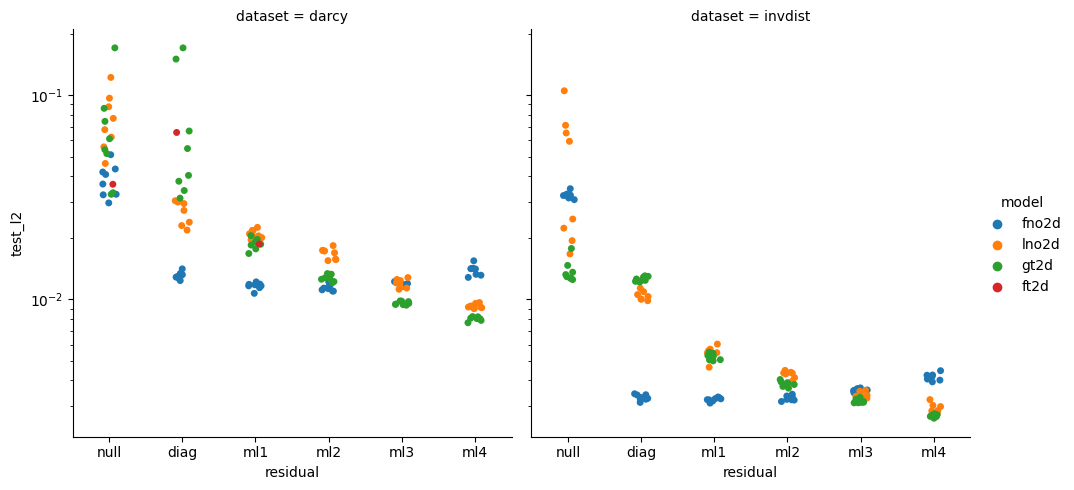

In [11]:
sub_df = log_df[(log_df.resolution == 106) & (log_df.coarse_level == 0)]# & (log_df.dataset != 'burgers')]
g = sns.catplot(data=sub_df, x='residual', y='test_l2', col='dataset', kind='strip', order=['null','diag','ml1', 'ml2', 'ml3', 'ml4'], hue='model')
g.set(yscale='log')

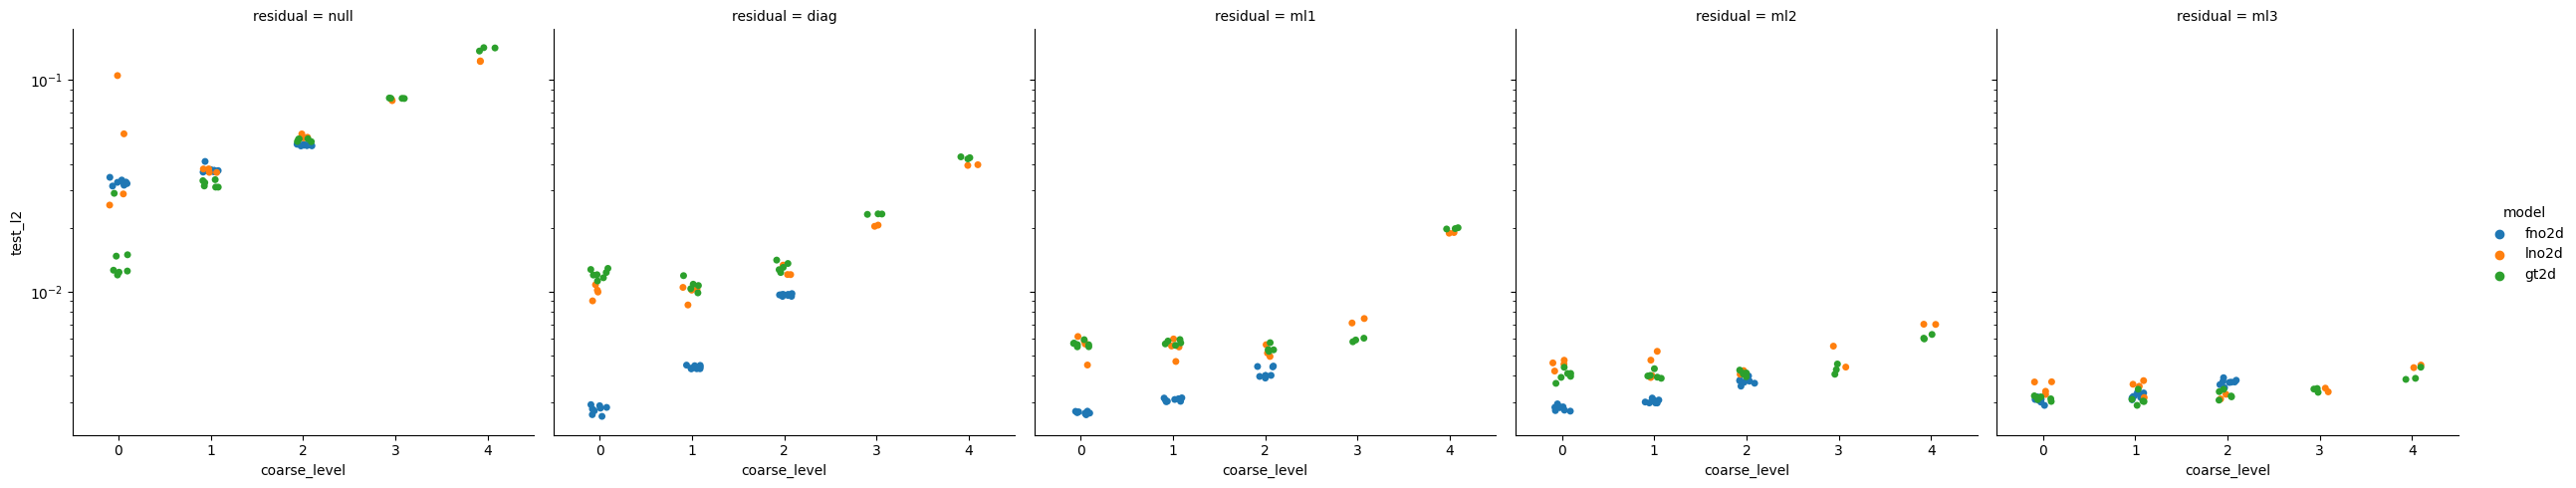

In [12]:
sub_df = log_df[(log_df.resolution == 141) & (log_df.dataset == 'invdist')]
g = sns.catplot(data=sub_df, x='coarse_level', y='test_l2', col='residual', kind='strip', order=[0, 1, 2, 3, 4], col_order=['null', 'diag', 'ml1', 'ml2', 'ml3'], hue='model')
g.set(yscale='log')

In [10]:
# sub_df = log_df[(log_df.resolution == 512) & (log_df.dataset == 'poisson') & (log_df.model == 'gt1d')]
# g = sns.catplot(data=sub_df, x='coarse_level', y='test_l2', col='residual', kind='strip', order=[0, 1, 2, 3, 4], col_order=['null', 'diag', 'ml1', 'ml2', 'ml3', 'ml4'], hue='model')
# g.set(yscale='log')